In [1]:
from mask2bbox import BBoxes
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from pathlib import Path
import seaborn as sns
import pandas as pd

In [20]:
# Get bounding boxes for one file
img_path = Path('../data/week5/segmentation/cellpose/s49c1.tif')

In [21]:
# Get bounding boxes for all files in a directory
img_box = BBoxes(img_path)

In [22]:
img_box.expand(20)

In [23]:
%%time
# Get IoU for the bounding boxes
pairs, values = img_box.overlapping_pairs()

CPU times: user 9.42 ms, sys: 703 µs, total: 10.1 ms
Wall time: 9.92 ms


[[ 13  15]
 [ 23  24]
 [ 20  21]
 [ 51  52]
 [ 45  47]
 [ 36  37]
 [105 106]
 [ 48  49]
 [ 11  13]
 [116 119]]
[0.60235999 0.599022   0.598      0.56796628 0.47460652 0.41991066
 0.38384792 0.34074074 0.33000965 0.31177094]


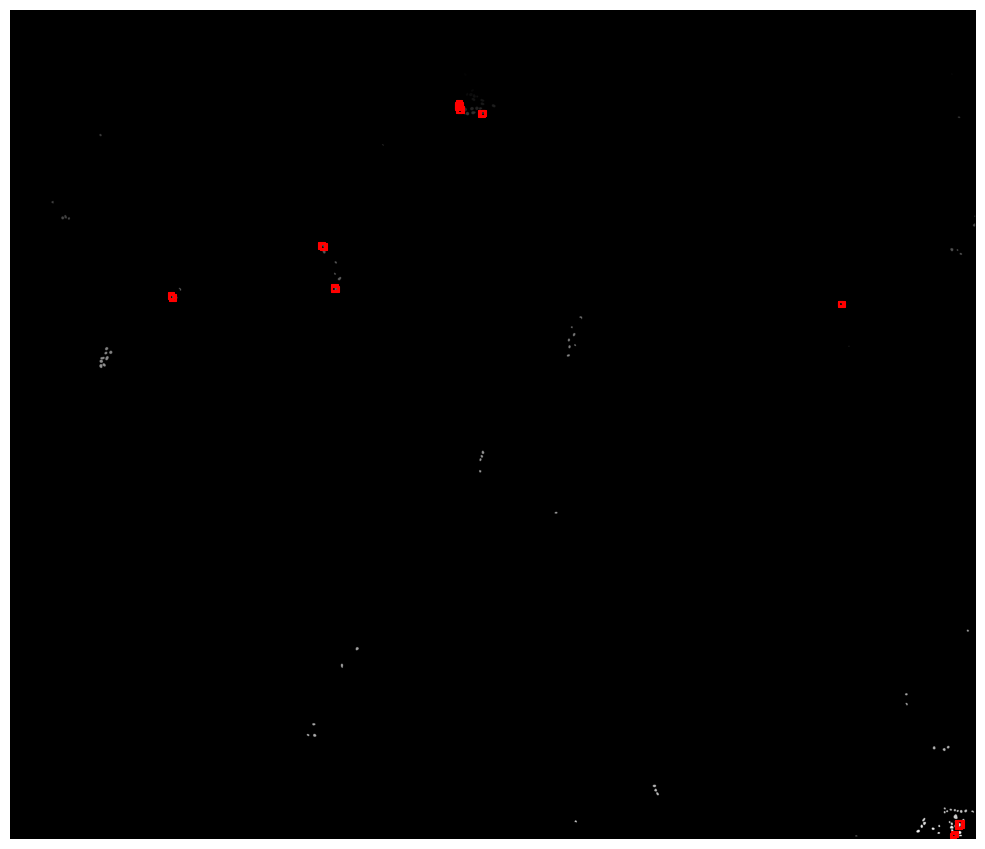

In [24]:
# Filter overlapping bounding boxes with IoU > 0.1
print(pairs[np.argsort(values)[::-1][:10]]) # Print the 10 pairs with highest IoU
print(values[np.argsort(values)[::-1][:10]]) # Print the 10 pairs with highest IoU
img_box.filter_identities(np.unique(pairs[np.argsort(values)[::-1][:10]])) # Filter the 10 pairs with highest IoU
img_box.plot_to_mask() # Plot the filtered bounding boxes

In [18]:
# Plot the IoU distribution
def plot_iou_distribution(values, name="", file=None):
    sns.set_style("white")
    fig, ax = plt.subplots(1, 2, figsize=(8, 5))
    sns.boxenplot(y=values, ax=ax[0])
    sns.boxenplot(y=np.log10(values), ax=ax[1])
    ax[0].hlines(0.5, -1, 1, color='red', linestyles='dashed')
    ax[1].hlines(np.log10(0.5), -1, 1, color='red', linestyles='dashed')
    ax[0].set_xlabel("IoU distribution")
    ax[1].set_xlabel("log10(IoU) distribution")
    ax[0].set_ylabel("IoU")
    ax[1].set_ylabel("log10(IoU)")
    fig.suptitle(f"IoU distribution for {name}")
    plt.close(fig)
    # plt.show()
    if file is not None:
        fig.savefig(file, dpi=300)

# # Create output directory
# out_path = Path(f"../data/week5/figures/{img_path.stem}_iou_distribution.png").resolve()
# out_path.parent.mkdir(parents=True, exist_ok=True)
#
# plot_iou_distribution(values, name=img_path.stem, file=out_path)

In [19]:
# Iterate over folder and get IoU for all files
img_dir = Path('../data/week5/segmentation/cellpose')
info = []
for file in img_dir.iterdir():
    try:
        # Create output file
        out_path = Path(f"../data/week5/figures/{file.stem}_iou_distribution.png").resolve()

        # Get bounding boxes
        img_box = BBoxes(file)

        # Expand bounding box to the desired size
        img_box.expand(20)

        # Get IoU
        pairs, values = img_box.overlapping_pairs()

        # Plot IoU distribution
        plot_iou_distribution(values, name=file.stem, file=out_path)

        # Save stats
        stats = {"Mean":np.mean(values),
                 "Bounding Boxes":len(values),
                 "0_overlap":np.sum(values == 0),
                 "10_overlap":np.sum(values > 0.1),
                 "20_overlap":np.sum(values > 0.2),
                 "30_overlap":np.sum(values > 0.3),
                 "40_overlap":np.sum(values > 0.4),
                 "50_overlap":np.sum(values > 0.5),
                 "overlap_ratio_10":np.sum(values > 0.1) / len(values),
                 "overlap_ratio_20":np.sum(values > 0.2) / len(values),
                 "overlap_ratio_30":np.sum(values > 0.3) / len(values),
                 "overlap_ratio_40":np.sum(values > 0.4) / len(values),
                 "overlap_ratio_50":np.sum(values > 0.5) / len(values),
                 "max":np.max(values),}

        # Make stats into a series
        info.append(pd.Series(stats, name=file.stem))

    except:
        print(f"Something went wrong with file {file}")

In [14]:
# Images with IoU > than 10% (0.1)
new_info = pd.concat(info, axis=1).T

In [15]:
new_info

,Mean,Bounding Boxes,0_overlap,10_overlap,20_overlap,30_overlap,40_overlap,50_overlap,overlap_ratio_10,overlap_ratio_20,overlap_ratio_30,overlap_ratio_40,overlap_ratio_50,max
s28c1,0.147037,18065.0,0.0,9836.0,5441.0,2514.0,730.0,62.0,0.544478,0.301190,0.139164,0.040410,0.003432,0.628476
s15c1,0.116801,2601.0,0.0,1108.0,546.0,231.0,75.0,6.0,0.425990,0.209919,0.088812,0.028835,0.002307,0.554545
s31c1,0.119942,2568.0,0.0,1109.0,586.0,253.0,51.0,5.0,0.431854,0.228193,0.098520,0.019860,0.001947,0.542727
s49c1,0.161138,118.0,0.0,71.0,35.0,11.0,6.0,4.0,0.601695,0.296610,0.093220,0.050847,0.033898,0.602360
s33c1,0.121164,2599.0,0.0,1100.0,579.0,289.0,79.0,11.0,0.423240,0.222778,0.111197,0.030396,0.004232,0.587896
s17c1,0.139855,19682.0,0.0,10350.0,5475.0,2420.0,616.0,71.0,0.525861,0.278173,0.122955,0.031298,0.003607,0.630600
s52c1,0.112952,7999.0,0.0,3272.0,1554.0,690.0,157.0,7.0,0.409051,0.194274,0.086261,0.019627,0.000875,0.619436
s13c1,0.124190,1617.0,0.0,698.0,404.0,174.0,40.0,2.0,0.431664,0.249845,0.107607,0.024737,0.001237,0.573609
s56c1,0.163937,11060.0,0.0,6523.0,3877.0,1950.0,667.0,97.0,0.589783,0.350542,0.176311,0.060307,0.008770,0.654407
s37c1,0.142126,21663.0,0.0,11479.0,6225.0,2739.0,775.0,92.0,0.529890,0.287356,0.126437,0.035775,0.004247,0.595718


In [ ]:
# Filter overlapping bounding boxes with IoU > 0.1
print(pairs[np.argsort(values)[::-1][:10]]) # Print the 10 pairs with highest IoU
img_box.filter_identities(np.unique(pairs[np.argsort(values)[::-1][:10]])) # Filter the 10 pairs with highest IoU
img_box.plot_to_mask() # Plot the filtered bounding boxes